# Genetic Algorithm Example: Robot Configuration Optimization

This notebook demonstrates how a **Genetic Algorithm (GA)** can be used to optimize the configuration of a **two–joint planar robot** in order to reach a target point in the workspace.

## Main Components

1. **Chromosome encoding**  
   The chromosome is a binary string representing two joint angles:
   - Left half $\rightarrow \theta_1$ 
   - Right half $\rightarrow \theta_2$ 

2. **Decoding**  
   Binary segments are converted to integers and scaled to the interval:

   $[0, 2\pi]$

3. **Fitness evaluation**  
   The fitness function is based on the **Euclidean distance** between the robot end–effector and the target point.

4. **Genetic operators**
   - Selection
   - Crossover
   - Mutation

5. **Experiments**
   The notebook explores how GA performance changes with:
   - Mutation probability
   - Crossover probability
   - Population size

---

## Objective

Find the pair of joint angles:

$(\theta_1, \theta_2)$

that minimizes the distance between the robot end‑effector and a goal point in the plane.

---

## Author
Dr. Juan Mauel Ahuactzin Larios

Date: March 03, 2023



In [1]:
import sys
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import math
import ipywidgets as widgets
from IPython.display import display, clear_output

from deap import base, creator, tools, algorithms

sys.path.append("..")
from common.homtransf import *
from common.robot_2D import *

<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 1. Chromosome decoding functions

<div style="text-align:center;">
    <img src="../images/decoding.png" style="height:400px; width:auto;">
</div>
</div>

In [2]:
def bits_to_angle(bits):
    """
    Convert a list of binary digits into an angle in the interval [0, 2π].

    The binary sequence is interpreted as an unsigned integer and then
    linearly scaled to the interval [0, 2π].

    This is a common technique in genetic algorithms when a binary
    chromosome must represent a continuous variable.

    Parameters
    ----------
    bits : list of int
        A list containing binary digits (0 or 1). Example:
        [1, 0, 1, 1, 0]

    Returns
    -------
    float
        A real-valued angle between 0 and 2π.

    Method
    ------
    1. Convert the binary list into an integer.
       Example:
           [1,0,1,1] → "1011" → 11

    2. Map the integer to the interval [0, 2π] using linear scaling:

           angle = integer / (2^n - 1) * 2π

       where n is the number of bits.

       This guarantees:
           smallest binary value → 0
           largest binary value  → 2π
    """

    n = len(bits)

    # Convert the binary list to an integer
    integer = int("".join(map(str, bits)), 2)

    # Linearly scale the integer to the interval [0, 2π]
    angle = integer / (2**n - 1) * 2 * math.pi

    return angle


def decode_individual(individual):
    """
    Decode a genetic algorithm chromosome into two joint angles.

    The chromosome is assumed to be divided into two equal halves:
    - the left half encodes θ₁
    - the right half encodes θ₂

    Each half is interpreted as a binary number and mapped to the
    interval [0, 2π].

    Parameters
    ----------
    individual : list of int
        Binary chromosome representing two angles.

        Example (20 bits):
            [θ₁ bits | θ₂ bits]

            [1,0,1,1,0,1,0,1,1,0, 0,1,1,1,0,0,1,0,1,1]

    Returns
    -------
    tuple
        (theta1, theta2) where both values are angles in radians
        within the interval [0, 2π].

    Process
    -------
    1. Split the chromosome into two equal parts.
    2. Convert each part from binary to a real angle.
    """

    # Half of the chromosome length
    mid_point = len(individual) // 2

    # First half encodes θ₁
    theta1_bits = individual[:mid_point]

    # Second half encodes θ₂
    theta2_bits = individual[mid_point:]

    # Convert both binary segments to angles
    theta1 = bits_to_angle(theta1_bits)
    theta2 = bits_to_angle(theta2_bits)

    return theta1, theta2

<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 2. Distance function

<div style="text-align:center;">
    <img src="../images/distance_robot_to_goal.png" style="height:400px; width:auto;">
</div>
</div>


In [3]:
def distance(x_goal, y_goal, x, y):
    """
    Compute the Euclidean distance between two points in the plane.

    Parameters
    ----------
    x_goal : float
        x-coordinate of the goal (target) point.

    y_goal : float
        y-coordinate of the goal (target) point.

    x : float
        x-coordinate of the end-effector point.

    y : float
        y-coordinate of the end-effector point.

    Returns
    -------
    float
        Euclidean distance between (x_goal, y_goal) and (x, y).

    Method
    ------
    The distance is computed using the Euclidean distance formula:

        distance = sqrt((x_goal - x)^2 + (y_goal - y)^2)
    """

    # Compute Euclidean distance between the goal and current position
    distance = math.sqrt((x_goal-x)**2 + (y_goal-y)**2)

    return distance

### 3. Robot and goal drawing functions

In [4]:
def draw_goal(x, y, ax=None):
    """
    Draw the goal position on a Matplotlib plot.

    Parameters
    ----------
    x : float
        x-coordinate of the goal point.

    y : float
        y-coordinate of the goal point.

    ax : matplotlib.axes.Axes, optional
        Axis where the goal will be drawn.
        If None, the current axis is used.
    """

    # If no axis is provided, use the current active axis
    if ax is None:
        ax = plt.gca()   # get current axis

    # Draw the goal point using a plus marker
    ax.scatter(x, y, marker='+')
    
def draw_robot_and_workspace(my_robot, theta_1, theta_2, x_goal, y_goal):
    """
    Visualize a robot configuration together with a target point in the workspace.

    This function updates the robot configuration using the provided joint angles,
    draws the robot in its current pose, and displays the goal position on the
    same plot.

    Parameters
    ----------
    my_robot : Robot object
        Robot model that provides:
        - set_conf([theta1, theta2]) to update its joint configuration
        - draw() to render the robot in the workspace

    theta_1 : float
        First joint angle (in radians).

    theta_2 : float
        Second joint angle (in radians).

    x_goal : float
        x-coordinate of the goal point.

    y_goal : float
        y-coordinate of the goal point.
    """

    # Update the robot configuration using the provided joint angles
    my_robot.set_conf([theta_1, theta_2])

    # Create a new square figure for visualization
    plt.figure(figsize=(6,6))

    # Draw the robot in its current configuration
    my_robot.draw()

    # Draw the goal point in the workspace
    draw_goal(x_goal, y_goal)

    # Ensure that x and y axes use the same scale
    # (important to avoid distortion of the robot geometry)
    plt.gca().set_aspect('equal', adjustable='box')

    # Display the joint angles in the plot title
    plt.title(f"Robot Configuration: Theta 1={theta_1:.2f}, Theta 2={theta_2:.2f}")

    # Show the final plot
    plt.show()

# =========================================================
# 1. FITNESS FUNCTION
# =========================================================

def eval_function(individual):
    global my_robot, x_goal, y_goal
    """
    Fitness function: counts the number of 1's in the individual.

    Parameters
    ----------
    individual : list
        Binary vector representing the individual.

    Returns
    -------
    tuple
        Fitness value (must be returned as a tuple in DEAP).
    """

    theta_1, theta_2 = decode_individual(individual)
    
    my_robot.set_conf([theta_1, theta_2])
    x_gripper, y_gripper = my_robot.direct_kinematics()

    dist = distance(x_goal, y_goal, x_gripper, y_gripper)


    return (dist,)

<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 4. GA definition: fitness, gene, individual, population

<div style="text-align:center;">
    <img src="../images/GA_Toolbox.png" style="height:400px; width:auto;">
</div>
</div>

In [5]:
# =========================================================
# 2. CREATE DEAP CLASSES (Only once per Python session)
# =========================================================
# DEAP dynamically creates classes for individuals and fitness.
# We check first to avoid errors if the notebook cell is run multiple times.

if not hasattr(creator, "fitness"):
    creator.create("fitness", base.Fitness, weights=(-1.0,))

if not hasattr(creator, "individual_container"):
    creator.create("individual_container", list, fitness=creator.fitness)

# =========================================================
# 3. TOOLBOX CONSTRUCTION
# =========================================================
def build_toolbox(ind_size=30, indpb=0.05, tournsize=3):
    """
    Builds and configures the DEAP toolbox.

    Parameters
    ----------
    ind_size : int
        Number of genes in each individual.

    indpb : float
        Probability of mutating each gene.

    tournsize : int
        Tournament size used for selection.

    Returns
    -------
    toolbox : deap.base.Toolbox
        Configured toolbox containing all operators.
    """

    toolbox = base.Toolbox()

    # Each gene is either 0 or 1
    toolbox.register("my_gene", random.randint, 0, 1)

    # An individual (or chromosome) is a list of binary genes
    toolbox.register(
        "individual",
        tools.initRepeat,
        creator.individual_container,
        toolbox.my_gene,
        ind_size
    )

    # Population = list of individuals
    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    # Register evaluation function
    toolbox.register("evaluate", eval_function)

    # Genetic operators
    toolbox.register("mate", tools.cxTwoPoint)

    # Bit-flip mutation
    toolbox.register("mutate", tools.mutFlipBit, indpb=indpb)

    # Tournament selection
    toolbox.register("select", tools.selTournament, tournsize=tournsize)

    return toolbox

### 5. Goal and robot selection variables

In [6]:
l = 20
w = 2

theta_1 = 0
theta_2 = 0

x_goal = 0
y_goal = 0

my_robot = PlanarRobot(l, w)

<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 6 Single-experiment runner

<div style="text-align:center;">
    <img src="../images/GA_parameters.png" style="height:400px; width:auto;">
</div>
</div>

In [7]:
# =========================================================
# 4. RUN A SINGLE EXPERIMENT
# =========================================================
def run_experiment(
    pop_size=50,
    cxpb=0.5,
    mutpb=0.2,
    n_gen=40,
    ind_size=30,
    indpb=0.05,
    seed=0
):
    """
    Runs a complete genetic algorithm experiment.

    Parameters
    ----------
    pop_size : int
        Number of individuals in the population.

    cxpb : float
        Probability of applying crossover.

    mutpb : float
        Probability of mutating an individual.

    n_gen : int
        Number of generations.

    ind_size : int
        Length of each individual's genome.

    indpb : float
        Probability of mutating each gene.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Dictionary containing statistics and the best solution found.
    """

    random.seed(seed)
    np.random.seed(seed)

    toolbox = build_toolbox(ind_size=ind_size, indpb=indpb)

    # Create initial population
    population = toolbox.population(n=pop_size)

    # Statistics to track during evolution
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    stats.register("min", np.min)

    # Hall of Fame keeps the best solution
    hof = tools.HallOfFame(1)

    # Run the evolutionary algorithm (In this case Genetic Algorithm)
    population, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=cxpb,
        mutpb=mutpb,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    # Extract statistics from the logbook
    generations = logbook.select("gen")
    avg_fitness = logbook.select("avg")
    max_fitness = logbook.select("max")
    min_fitness = logbook.select("min")

    return {
        "generations": generations,
        "avg": avg_fitness,
        "max": max_fitness,
        "min": min_fitness,
        "best_individual": hof[0],
        "best_fitness": hof[0].fitness.values[0]
    }



<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 7 Multiple-experiments runner

<div style="text-align:center;">
    <img src="../images/GA_list_of_parameters.png" style="height:400px; width:auto;">
</div>
</div>

In [8]:
# =========================================================
# 5. COMPARE MULTIPLE EXPERIMENTS
# =========================================================
def compare_experiments(configs, n_gen=40, ind_size=30, indpb=0.05, seed=0):
    """
    Runs multiple GA experiments with different parameters and plots results.

    Parameters
    ----------
    configs : list of dict
        List of parameter configurations to test.

    n_gen : int
        Number of generations.

    ind_size : int
        Genome length.

    indpb : float
        Gene mutation probability.

    seed : int
        Random seed.
    """

    plt.figure(figsize=(10, 6))

    all_results = []

    for config in configs:

        result = run_experiment(
            pop_size=config["pop_size"],
            cxpb=config["cxpb"],
            mutpb=config["mutpb"],
            n_gen=n_gen,
            ind_size=ind_size,
            indpb=indpb,
            seed=seed
        )

        all_results.append(result)

        label = (
            f'pop={config["pop_size"]}, '
            f'cxpb={config["cxpb"]}, '
            f'mutpb={config["mutpb"]}'
        )

        plt.plot(result["generations"], result["min"], label=label)

    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("Genetic Algorithm Convergence Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Draws the best solution of each experiment
    for i, result in enumerate(all_results):
        best_individual = result["best_individual"]
        best_fitness = result["best_fitness"]

        theta_1, theta_2 = decode_individual(best_individual)

        draw_robot_and_workspace(my_robot, theta_1, theta_2, x_goal, y_goal)

        print("Best individual:", best_individual)
        print("Best fitness:", best_fitness)

### 8. Configuration selection interface

In [9]:
# Output area
out = widgets.Output()

# Sliders
x_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="x_goal", continuous_update=False
)

y_slider = widgets.FloatSlider(
    value=0.0, min=-2*l, max=2*l, step=(4*l)/200,
    description="y_goal", continuous_update=False
)

def update_plot(x_goal_f, y_goal_f, deg_theta1=0, deg_theta2=0):
    global x_goal, y_goal
    with out:
        clear_output(wait=True)

        theta_1 = np.deg2rad(deg_theta1)
        theta_2 = np.deg2rad(deg_theta2)
        x_goal = x_goal_f
        y_goal = y_goal_f

        # Set the robot at the configuration theta_1 and theta_2
        my_robot.set_conf([theta_1, theta_2])
        x_gripper, y_gripper = my_robot.direct_kinematics()

        # Compute the distance
        dist = distance(x_goal, y_goal, x_gripper, y_gripper)

        plt.figure(figsize=(6,6))   # importante
        my_robot.draw()
        draw_goal(x_goal, y_goal)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.title(f"Distance: {dist:.3f} | θ(rad)=({theta_1:.3f},{theta_2:.3f})")
        plt.show()


controls = widgets.interactive_output(
    update_plot,
    {
        "x_goal_f": x_slider,
        "y_goal_f": y_slider,
    }
)

ui = widgets.VBox([
    widgets.HBox([x_slider, y_slider]),
    out
])

display(ui)

### 9. Fixed parameters experiment 

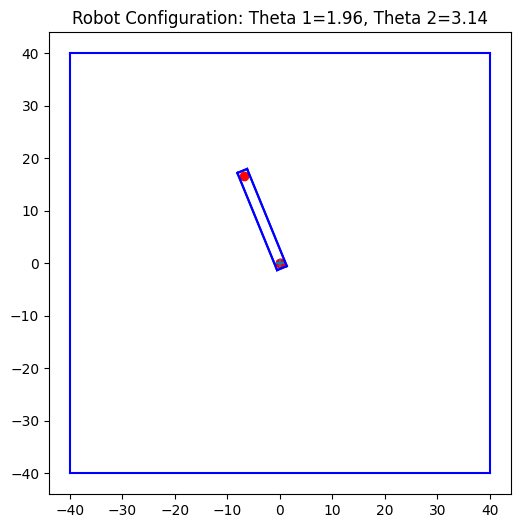

Best individual: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667527


In [10]:
# =========================================================
# 6. EXAMPLE USAGE
# =========================================================

# Run a baseline experiment
base_result = run_experiment(
    pop_size=50,
    cxpb=0.5,
    mutpb=0.2,
    n_gen=40,
    ind_size=30,
    indpb=0.05,
    seed=42
)

best_individual = base_result["best_individual"]
best_fitness = base_result["best_fitness"]

theta_1, theta_2 = decode_individual(best_individual)

draw_robot_and_workspace(my_robot, theta_1, theta_2, x_goal, y_goal)

print("Best individual:", best_individual)
print("Best fitness:", best_fitness)

### 10. Mutation probability experiments

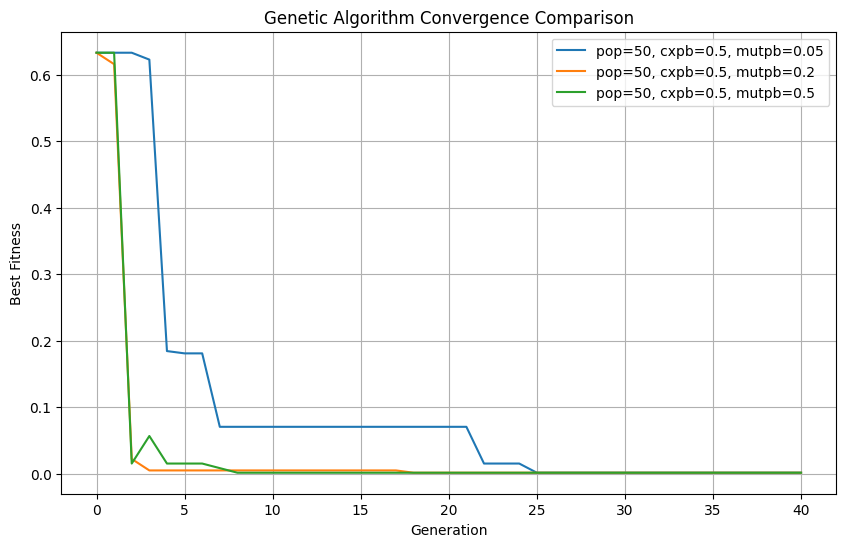

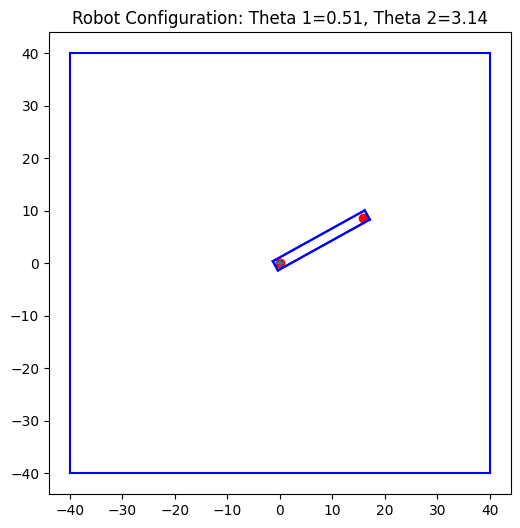

Best individual: [0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667633


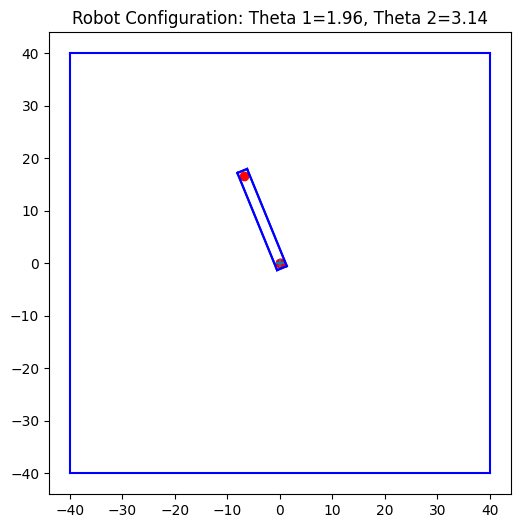

Best individual: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667527


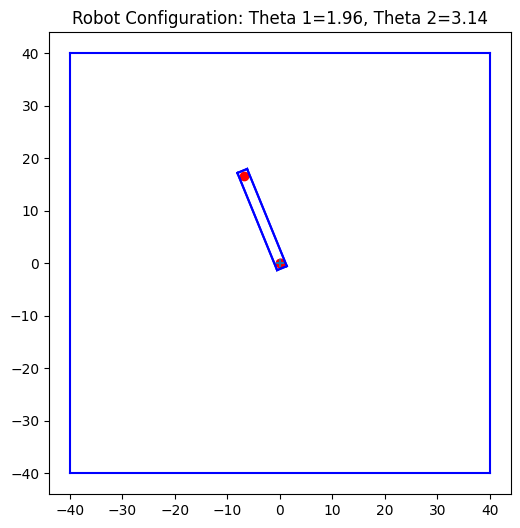

Best individual: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Best fitness: 0.001725781052370998


In [11]:
# ---------------------------------------------------------
# Experiment 1: Vary mutation probability
# ---------------------------------------------------------
configs_mutation = [
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.05},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.20},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.50},
]

compare_experiments(configs_mutation, n_gen=40, ind_size=30, indpb=0.05, seed=42)

### 11.  Crossover probability experiments

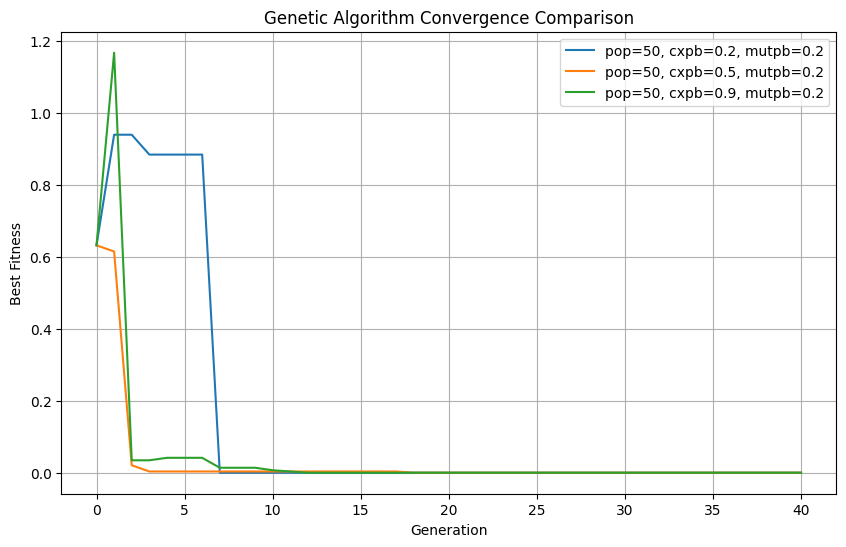

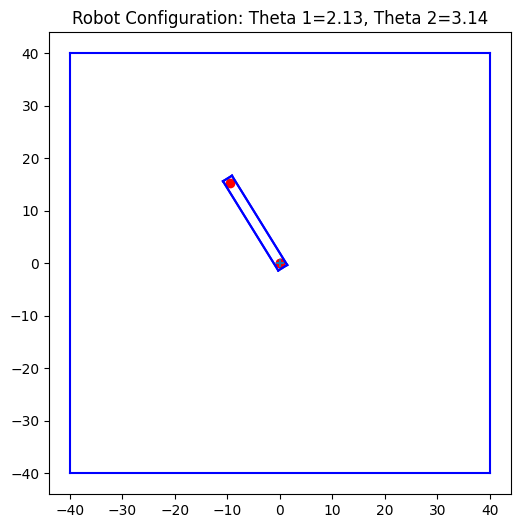

Best individual: [0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Best fitness: 0.0017257810523703392


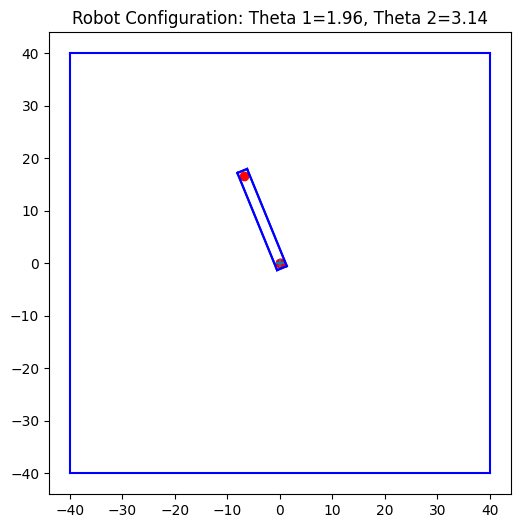

Best individual: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667527


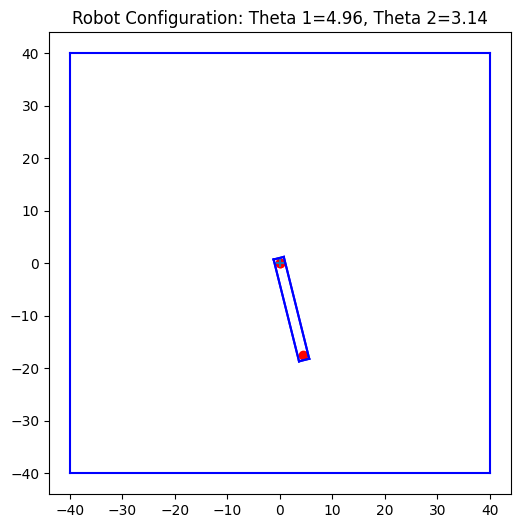

Best individual: [1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667954


In [12]:
# ---------------------------------------------------------
# Experiment 2: Vary crossover probability
# ---------------------------------------------------------
configs_crossover = [
    {"pop_size": 50, "cxpb": 0.2, "mutpb": 0.2},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 50, "cxpb": 0.9, "mutpb": 0.2},
]

compare_experiments(configs_crossover, n_gen=40, ind_size=30, indpb=0.05, seed=42)

### 12. Population size experiments

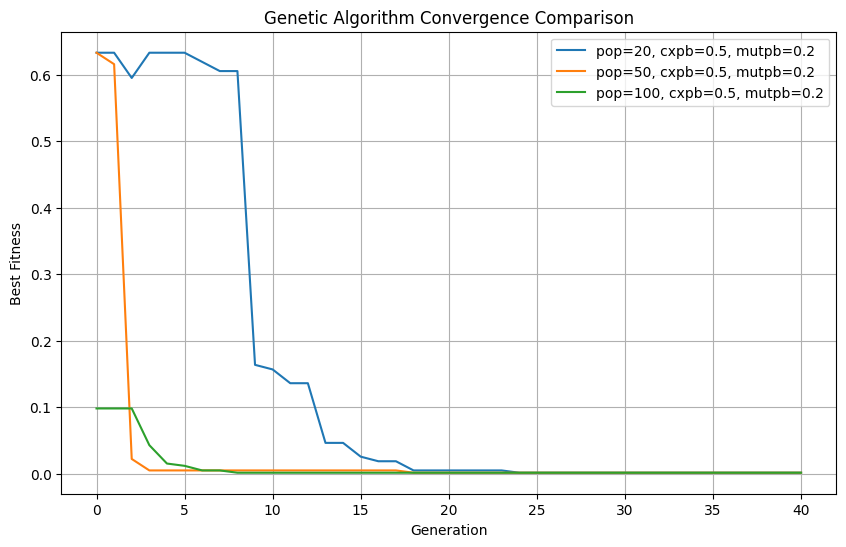

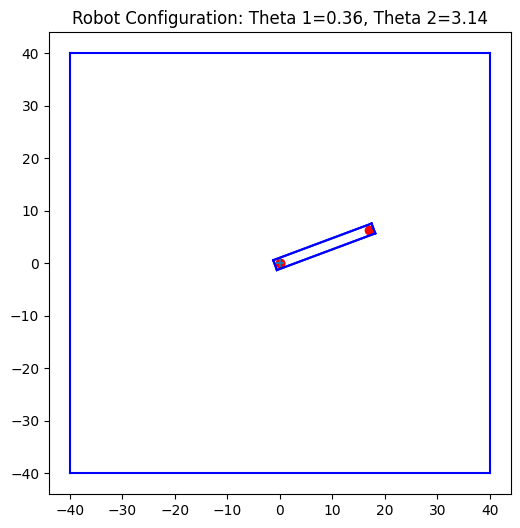

Best individual: [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667657


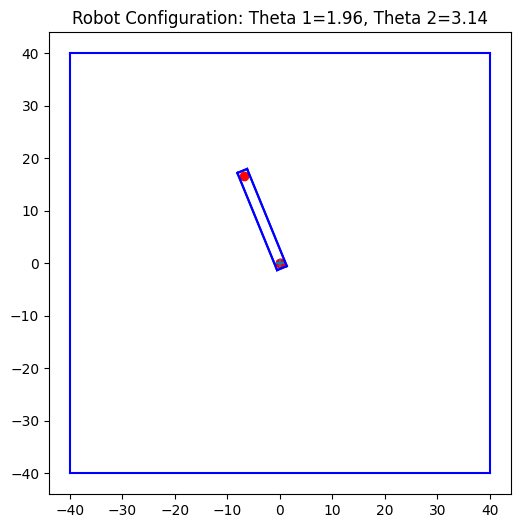

Best individual: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523667527


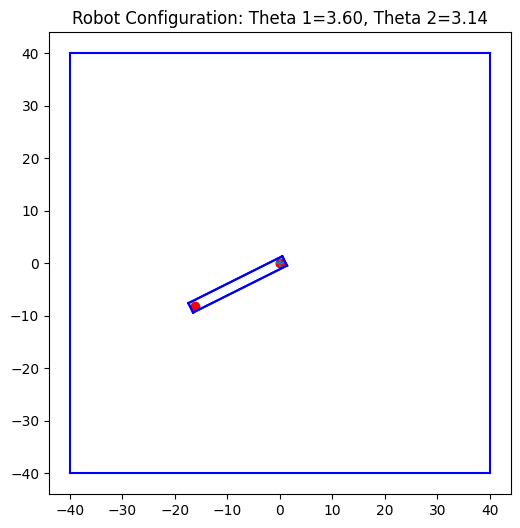

Best individual: [1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.0017257810523656867


In [13]:
# ---------------------------------------------------------
# Experiment 3: Vary population size
# ---------------------------------------------------------
configs_population = [
    {"pop_size": 20, "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 100, "cxpb": 0.5, "mutpb": 0.2},
]

compare_experiments(configs_population, n_gen=40, ind_size=30, indpb=0.05, seed=42)